<a href="https://colab.research.google.com/github/Muslunun/mml-book.github.io/blob/master/2store_tekrar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pycaret

In [ ]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Kitap1.xlsx to Kitap1 (1).xlsx


In [ ]:
import io
df=pd.read_excel(io.BytesIO(uploaded['Kitap1 (1).xlsx']))
df

,Name,ZnO(wt%),zhap,T °C,Store,Loss,Tan Delta
0,PHBV,0.0,0.0,-28.9625,4.054542,7.457634,0.018393
1,PHBV,0.0,0.0,-27.8000,4.052176,7.183828,0.017728
2,PHBV,0.0,0.0,-27.2500,4.050986,7.298008,0.018015
3,PHBV,0.0,0.0,-27.0000,4.051496,7.200067,0.017771
4,PHBV,0.0,0.0,-26.8000,4.053380,7.105970,0.017531
...,...,...,...,...,...,...,...
8084,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.0375,0.537518,7.174341,0.133472
8085,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.1875,0.530107,6.792890,0.128142
8086,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.3250,0.528821,6.868709,0.129887
8087,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.4750,0.527478,6.869602,0.130235


In [ ]:
from pycaret.regression import *
s = setup(df, target = 'Store', session_id = 123)

,Description,Value
0,Session id,123
1,Target,Store
2,Target type,Regression
3,Original data shape,"(8089, 7)"
4,Transformed data shape,"(8089, 12)"
5,Transformed train set shape,"(5662, 12)"
6,Transformed test set shape,"(2427, 12)"
7,Numeric features,5
8,Categorical features,1
9,Preprocess,True


In [ ]:
best = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.0056,0.0001,0.0093,1.0000,0.0029,0.0029,1.8660
et,Extra Trees Regressor,0.0033,0.0000,0.0055,1.0000,0.0015,0.0015,1.1870
knn,K Neighbors Regressor,0.0043,0.0003,0.0127,0.9999,0.0023,0.0019,0.0690
lightgbm,Light Gradient Boosting Machine,0.0140,0.0004,0.0202,0.9999,0.0062,0.0077,0.3970
xgboost,Extreme Gradient Boosting,0.0127,0.0004,0.0201,0.9999,0.0058,0.0067,0.1560
dt,Decision Tree Regressor,0.0092,0.0003,0.0180,0.9999,0.0060,0.0051,0.0770
gbr,Gradient Boosting Regressor,0.0446,0.0039,0.0624,0.9990,0.0178,0.0229,0.7710
ada,AdaBoost Regressor,0.3372,0.1468,0.3831,0.9640,0.1239,0.2248,0.4040
br,Bayesian Ridge,0.4140,0.3112,0.5578,0.9237,0.1500,0.2909,0.0580
lar,Least Angle Regression,0.4141,0.3112,0.5577,0.9237,0.1501,0.2904,0.0550


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
predict_model(best)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,0.0050,0.0001,0.0080,1.0000,0.0024,0.0025


,Name,ZnO(wt%),zhap,T °C,Loss,Tan Delta,Store,prediction_label
1491,PHBV-ZnO5,5.0,0.0,-8.500000,17.714750,0.021862,8.103026,8.096630
5941,PHBV-ZnO5ZHAP0.5,5.0,0.5,39.700001,7.339619,0.033077,2.218956,2.222884
5628,PHBV-ZnO5ZHAP0.5,5.0,0.5,-2.775000,8.308531,0.025317,3.281787,3.282440
5197,PHBV-ZnO3ZHAP0.5,3.0,0.5,122.349998,8.138097,0.108266,0.751673,0.753330
6902,PHBV-ZnO5ZHAP0.1,5.0,0.1,-12.000000,13.536929,0.021605,6.265529,6.272756
...,...,...,...,...,...,...,...,...
1207,PHBV,0.0,0.0,137.899994,5.234184,0.148023,0.353605,0.355366
4842,PHBV-ZnO3ZHAP0.5,3.0,0.5,74.349998,7.456329,0.050107,1.488068,1.487371
159,PHBV,0.0,0.0,-5.400000,8.191697,0.021667,3.780639,3.777646
5763,PHBV-ZnO5ZHAP0.5,5.0,0.5,15.312500,12.168466,0.042717,2.848610,2.857775


In [ ]:
ada = create_model('ada')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3465,0.1584,0.3980,0.9617,0.1349,0.2510
1,0.3376,0.1476,0.3842,0.9616,0.1222,0.2149
2,0.3328,0.1454,0.3813,0.9625,0.1256,0.2367
3,0.3408,0.1494,0.3865,0.9632,0.1213,0.2182
4,0.3441,0.1470,0.3833,0.9650,0.1266,0.2305
5,0.3391,0.1479,0.3846,0.9651,0.1205,0.2125
6,0.3477,0.1538,0.3922,0.9598,0.1240,0.2261
7,0.3255,0.1430,0.3782,0.9658,0.1193,0.2155
8,0.3177,0.1313,0.3623,0.9679,0.1156,0.2025


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
dt  = create_model('dt')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0081,0.0002,0.0131,1.0000,0.0043,0.0048
1,0.0095,0.0002,0.0147,0.9999,0.0053,0.0055
2,0.0091,0.0003,0.0183,0.9999,0.0059,0.0055
3,0.0097,0.0006,0.0239,0.9999,0.0084,0.0054
4,0.0088,0.0002,0.0157,0.9999,0.0050,0.0046
5,0.0091,0.0002,0.0155,0.9999,0.0045,0.0048
6,0.0094,0.0004,0.0203,0.9999,0.0066,0.0049
7,0.0091,0.0005,0.0231,0.9999,0.0080,0.0047
8,0.0094,0.0003,0.0164,0.9999,0.0056,0.0055


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
et  = create_model('et')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0033,0.0000,0.0049,1.0000,0.0013,0.0016
1,0.0036,0.0000,0.0070,1.0000,0.0025,0.0018
2,0.0031,0.0000,0.0052,1.0000,0.0015,0.0016
3,0.0034,0.0000,0.0057,1.0000,0.0014,0.0015
4,0.0033,0.0000,0.0057,1.0000,0.0014,0.0014
5,0.0033,0.0000,0.0055,1.0000,0.0014,0.0015
6,0.0033,0.0000,0.0052,1.0000,0.0014,0.0015
7,0.0034,0.0000,0.0056,1.0000,0.0014,0.0015
8,0.0031,0.0000,0.0049,1.0000,0.0015,0.0015


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

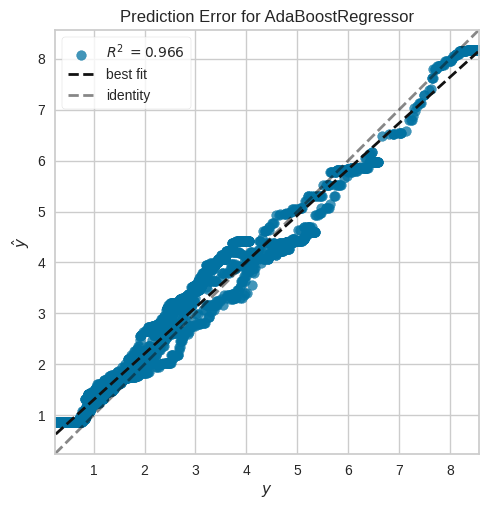

In [ ]:
plot_model(ada, plot = 'error')

In [ ]:
predict_model(ada)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,AdaBoost Regressor,0.3236,0.1379,0.3714,0.9662,0.1173,0.2066


,Name,ZnO(wt%),zhap,T °C,Loss,Tan Delta,Store,prediction_label
1491,PHBV-ZnO5,5.0,0.0,-8.500000,17.714750,0.021862,8.103026,8.051323
5941,PHBV-ZnO5ZHAP0.5,5.0,0.5,39.700001,7.339619,0.033077,2.218956,2.754668
5628,PHBV-ZnO5ZHAP0.5,5.0,0.5,-2.775000,8.308531,0.025317,3.281787,3.897675
5197,PHBV-ZnO3ZHAP0.5,3.0,0.5,122.349998,8.138097,0.108266,0.751673,0.872549
6902,PHBV-ZnO5ZHAP0.1,5.0,0.1,-12.000000,13.536929,0.021605,6.265529,5.857243
...,...,...,...,...,...,...,...,...
1207,PHBV,0.0,0.0,137.899994,5.234184,0.148023,0.353605,0.857531
4842,PHBV-ZnO3ZHAP0.5,3.0,0.5,74.349998,7.456329,0.050107,1.488068,1.753527
159,PHBV,0.0,0.0,-5.400000,8.191697,0.021667,3.780639,4.398656
5763,PHBV-ZnO5ZHAP0.5,5.0,0.5,15.312500,12.168466,0.042717,2.848610,3.375147


In [ ]:
predict_model(et)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.0031,0.0000,0.0050,1.0000,0.0013,0.0014


,Name,ZnO(wt%),zhap,T °C,Loss,Tan Delta,Store,prediction_label
1491,PHBV-ZnO5,5.0,0.0,-8.500000,17.714750,0.021862,8.103026,8.099302
5941,PHBV-ZnO5ZHAP0.5,5.0,0.5,39.700001,7.339619,0.033077,2.218956,2.220798
5628,PHBV-ZnO5ZHAP0.5,5.0,0.5,-2.775000,8.308531,0.025317,3.281787,3.282921
5197,PHBV-ZnO3ZHAP0.5,3.0,0.5,122.349998,8.138097,0.108266,0.751673,0.753813
6902,PHBV-ZnO5ZHAP0.1,5.0,0.1,-12.000000,13.536929,0.021605,6.265529,6.270649
...,...,...,...,...,...,...,...,...
1207,PHBV,0.0,0.0,137.899994,5.234184,0.148023,0.353605,0.355383
4842,PHBV-ZnO3ZHAP0.5,3.0,0.5,74.349998,7.456329,0.050107,1.488068,1.485472
159,PHBV,0.0,0.0,-5.400000,8.191697,0.021667,3.780639,3.779056
5763,PHBV-ZnO5ZHAP0.5,5.0,0.5,15.312500,12.168466,0.042717,2.848610,2.853171


In [ ]:
predict_model(dt)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Decision Tree Regressor,0.0082,0.0002,0.0133,1.0000,0.0043,0.0044


,Name,ZnO(wt%),zhap,T °C,Loss,Tan Delta,Store,prediction_label
1491,PHBV-ZnO5,5.0,0.0,-8.500000,17.714750,0.021862,8.103026,8.093703
5941,PHBV-ZnO5ZHAP0.5,5.0,0.5,39.700001,7.339619,0.033077,2.218956,2.221866
5628,PHBV-ZnO5ZHAP0.5,5.0,0.5,-2.775000,8.308531,0.025317,3.281787,3.277378
5197,PHBV-ZnO3ZHAP0.5,3.0,0.5,122.349998,8.138097,0.108266,0.751673,0.755718
6902,PHBV-ZnO5ZHAP0.1,5.0,0.1,-12.000000,13.536929,0.021605,6.265529,6.271414
...,...,...,...,...,...,...,...,...
1207,PHBV,0.0,0.0,137.899994,5.234184,0.148023,0.353605,0.355300
4842,PHBV-ZnO3ZHAP0.5,3.0,0.5,74.349998,7.456329,0.050107,1.488068,1.488060
159,PHBV,0.0,0.0,-5.400000,8.191697,0.021667,3.780639,3.782654
5763,PHBV-ZnO5ZHAP0.5,5.0,0.5,15.312500,12.168466,0.042717,2.848610,2.852485


In [ ]:
holdout_pred2 = predict_model(et)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.0031,0.0000,0.0050,1.0000,0.0013,0.0014


In [ ]:
holdout_pred3 = predict_model(ada)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,AdaBoost Regressor,0.3236,0.1379,0.3714,0.9662,0.1173,0.2066


In [ ]:
holdout_pred2 = predict_model(dt)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Decision Tree Regressor,0.0082,0.0002,0.0133,1.0000,0.0043,0.0044


In [ ]:
new_data = df.copy()
new_data.drop('Store', axis=1, inplace=True)
new_data.head()

,Name,ZnO(wt%),zhap,T °C,Loss,Tan Delta
0,PHBV,0.0,0.0,-28.9625,7.457634,0.018393
1,PHBV,0.0,0.0,-27.8000,7.183828,0.017728
2,PHBV,0.0,0.0,-27.2500,7.298008,0.018015
3,PHBV,0.0,0.0,-27.0000,7.200067,0.017771
4,PHBV,0.0,0.0,-26.8000,7.105970,0.017531


In [ ]:
predictions2 = predict_model(ada, data = new_data)
predictions2

,Name,ZnO(wt%),zhap,T °C,Loss,Tan Delta,prediction_label
0,PHBV,0.0,0.0,-28.962500,7.457634,0.018393,4.531721
1,PHBV,0.0,0.0,-27.799999,7.183828,0.017728,4.531721
2,PHBV,0.0,0.0,-27.250000,7.298008,0.018015,4.531721
3,PHBV,0.0,0.0,-27.000000,7.200067,0.017771,4.531721
4,PHBV,0.0,0.0,-26.799999,7.105970,0.017531,4.423709
...,...,...,...,...,...,...,...
8084,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.037506,7.174341,0.133472,0.857531
8085,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.187500,6.792890,0.128142,0.857531
8086,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.324997,6.868709,0.129887,0.857531
8087,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.475006,6.869602,0.130235,0.857531


In [ ]:
predictions2 = predict_model(ada, data = new_data)
predictions2

,Name,ZnO(wt%),zhap,T °C,Loss,Tan Delta,prediction_label
0,PHBV,0.0,0.0,-28.962500,7.457634,0.018393,4.531721
1,PHBV,0.0,0.0,-27.799999,7.183828,0.017728,4.531721
2,PHBV,0.0,0.0,-27.250000,7.298008,0.018015,4.531721
3,PHBV,0.0,0.0,-27.000000,7.200067,0.017771,4.531721
4,PHBV,0.0,0.0,-26.799999,7.105970,0.017531,4.423709
...,...,...,...,...,...,...,...
8084,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.037506,7.174341,0.133472,0.857531
8085,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.187500,6.792890,0.128142,0.857531
8086,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.324997,6.868709,0.129887,0.857531
8087,PHBV-ZnO5ZHAP0.1,5.0,0.1,149.475006,6.869602,0.130235,0.857531


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=predictions2)

https://docs.google.com/spreadsheets/d/1uoHqpp8oB6sI3tBvn-Uofv3uRHyXNebY7QT-UlxERJA/edit#gid=0


In [ ]:
predictions

NameError: name 'predictions' is not defined

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=predictions)

https://docs.google.com/spreadsheets/d/1OzJ6WchjwCLPCVo8Xcf4BPdqMMC4RkxdJQ-iJBR7Br0#gid=0


In [ ]:
import pandas as pd
import numpy as np

zhap_values = np.arange(0, 5.1, 0.1)
zno_values = np.zeros_like(zhap_values)

# Diğer sütunlara sabit değer verelim (istersen değiştirebilirsin)
new_data = pd.DataFrame({
    'Name': ['Sample'] * len(zhap_values),      # string sütun varsa sabit string verebilirsin
    'T °C': [25] * len(zhap_values),             # sıcaklık: örneğin 25 °C
    'Loss': [0.01] * len(zhap_values),           # loss: örnek bir değer
    'Tan Delta': [0.05] * len(zhap_values),      # tan delta: örnek bir değer
    'ZnO(wt%)': zno_values,
    'zhap': zhap_values
})

In [ ]:
new_data

,Name,T °C,Loss,Tan Delta,ZnO(wt%),zhap
0,Sample,25,0.01,0.05,0.0,0.0
1,Sample,25,0.01,0.05,0.0,0.1
2,Sample,25,0.01,0.05,0.0,0.2
3,Sample,25,0.01,0.05,0.0,0.3
4,Sample,25,0.01,0.05,0.0,0.4
5,Sample,25,0.01,0.05,0.0,0.5
6,Sample,25,0.01,0.05,0.0,0.6
7,Sample,25,0.01,0.05,0.0,0.7
8,Sample,25,0.01,0.05,0.0,0.8
9,Sample,25,0.01,0.05,0.0,0.9


In [ ]:
predictionx = predict_model(ada, data=new_data)
predictionx

,Name,T °C,Loss,Tan Delta,ZnO(wt%),zhap,prediction_label
0,Sample,25,0.01,0.05,0.0,0.0,3.526068
1,Sample,25,0.01,0.05,0.0,0.1,3.526068
2,Sample,25,0.01,0.05,0.0,0.2,3.526068
3,Sample,25,0.01,0.05,0.0,0.3,3.100143
4,Sample,25,0.01,0.05,0.0,0.4,3.100143
5,Sample,25,0.01,0.05,0.0,0.5,3.100143
6,Sample,25,0.01,0.05,0.0,0.6,3.100143
7,Sample,25,0.01,0.05,0.0,0.7,3.100143
8,Sample,25,0.01,0.05,0.0,0.8,3.100143
9,Sample,25,0.01,0.05,0.0,0.9,3.100143


In [ ]:
import pandas as pd
import numpy as np

# zhap: 0'dan 5'e kadar 0.1 artışla
zhap_values = np.arange(0, 5.1, 0.1)

# ZnO(wt%): hepsi 0
zno_values = np.zeros_like(zhap_values)

# T °C: -20 ile 150 arasında eşit uzunlukta
t_values = np.linspace(-20, 150, len(zhap_values))

# Sabit diğer değerler:
loss_values = [0.01] * len(zhap_values)
tan_delta_values = [0.05] * len(zhap_values)
name_values = ['Sample'] * len(zhap_values)

# Yeni DataFrame
new_data2 = pd.DataFrame({
    'Name': name_values,
    'T °C': t_values,
    'Loss': loss_values,
    'Tan Delta': tan_delta_values,
    'ZnO(wt%)': zno_values,
    'zhap': zhap_values
})

new_data2


,Name,T °C,Loss,Tan Delta,ZnO(wt%),zhap
0,Sample,-20.0,0.01,0.05,0.0,0.0
1,Sample,-16.6,0.01,0.05,0.0,0.1
2,Sample,-13.2,0.01,0.05,0.0,0.2
3,Sample,-9.8,0.01,0.05,0.0,0.3
4,Sample,-6.4,0.01,0.05,0.0,0.4
5,Sample,-3.0,0.01,0.05,0.0,0.5
6,Sample,0.4,0.01,0.05,0.0,0.6
7,Sample,3.8,0.01,0.05,0.0,0.7
8,Sample,7.2,0.01,0.05,0.0,0.8
9,Sample,10.6,0.01,0.05,0.0,0.9


In [ ]:
predictions = predict_model(ada, data=new_data2)
predictions

,Name,T °C,Loss,Tan Delta,ZnO(wt%),zhap,prediction_label
0,Sample,-20.000000,0.01,0.05,0.0,0.0,4.423709
1,Sample,-16.600000,0.01,0.05,0.0,0.1,4.423709
2,Sample,-13.200000,0.01,0.05,0.0,0.2,4.423709
3,Sample,-9.800000,0.01,0.05,0.0,0.3,4.220119
4,Sample,-6.400000,0.01,0.05,0.0,0.4,4.146362
5,Sample,-3.000000,0.01,0.05,0.0,0.5,4.089488
6,Sample,0.400000,0.01,0.05,0.0,0.6,4.045114
7,Sample,3.800000,0.01,0.05,0.0,0.7,3.956343
8,Sample,7.200000,0.01,0.05,0.0,0.8,3.803012
9,Sample,10.600000,0.01,0.05,0.0,0.9,3.729871


from matplotlib import pyplot as plt
_df_0['T °C'].plot(kind='hist', bins=20, title='T °C')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['zhap'].plot(kind='hist', bins=20, title='zhap')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['prediction_label'].plot(kind='hist', bins=20, title='prediction_label')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3.plot(kind='scatter', x='T °C', y='zhap', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Loss']
  ys = series['prediction_label']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_7.sort_values('Loss', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Loss')
_ = plt.ylabel('prediction_label')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Loss']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Loss'}, axis=1)
              .sort_values('Loss', ascending=True))
  xs = counted['Loss']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_8.sort_values('Loss', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Loss')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_9['T °C'].plot(kind='line', figsize=(8, 4), title='T °C')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['zhap'].plot(kind='line', figsize=(8, 4), title='zhap')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['prediction_label'].plot(kind='line', figsize=(8, 4), title='prediction_label')
plt.gca().spines[['top', 'right']].set_visible(False)

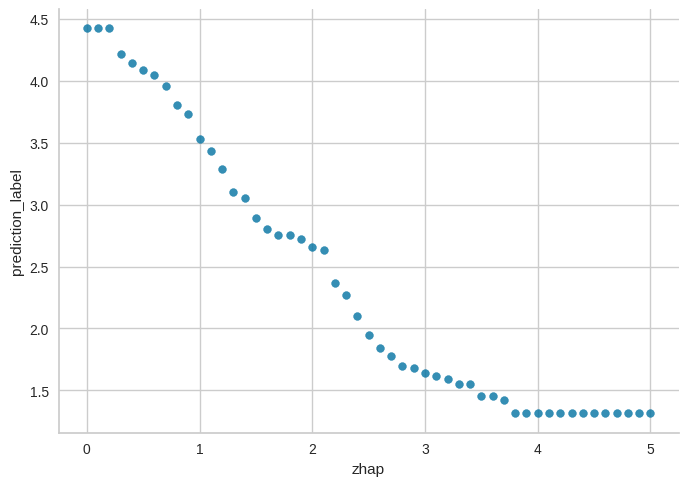

In [ ]:
from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='zhap', y='prediction_label', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

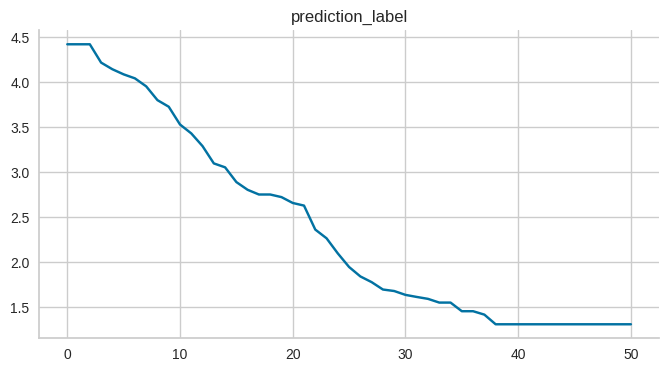

In [ ]:
from matplotlib import pyplot as plt
_df_11['prediction_label'].plot(kind='line', figsize=(8, 4), title='prediction_label')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# 1. Yeni zhap ve sıcaklık değerleri
import numpy as np
import pandas as pd

zhap_values = np.arange(0, 5.1, 0.1)
temperature_values = np.linspace(-20, 140, len(zhap_values))

# Diğer özellikleri sabit tutalım (istersen sonra değiştirebiliriz)
name_values = ['Sample'] * len(zhap_values)
zno_values = np.zeros_like(zhap_values)

# Ortalamadan alınmış sabit değerler
store_dummy = [1] * len(zhap_values)  # hedef sütun eklenecek, dummy
loss_dummy = [0.01] * len(zhap_values)
tan_delta_dummy = [0.05] * len(zhap_values)

new_data_base = pd.DataFrame({
    'Name': name_values,
    'T °C': temperature_values,
    'Loss': loss_dummy,
    'Tan Delta': tan_delta_dummy,
    'ZnO(wt%)': zno_values,
    'zhap': zhap_values,
    'Store': store_dummy  # placeholder
})


In [ ]:
from pycaret.regression import *

# Store için model
s_store = setup(df, target='Store', session_id=123)
model_store = create_model('et')

# Loss için model
s_loss = setup(df, target='Loss', session_id=123)
model_loss = create_model('et')

# Tan Delta için model
s_td = setup(df, target='Tan Delta', session_id=123)
model_td = create_model('et')

# Prepare data for prediction
prediction_data = new_data_base.drop('Store', axis=1)

# Store tahmini
pred_store = predict_model(model_store, data=prediction_data)

# Loss tahmini
pred_loss = predict_model(model_loss, data=prediction_data.drop(['Pred_Store'], axis=1, errors='ignore'))

# Tan Delta tahmini
pred_td = predict_model(model_td, data=prediction_data.drop(['Pred_Store', 'Pred_Loss'], axis=1, errors='ignore'))

# Tüm tahminleri birleştir
final_predictions = pd.DataFrame({
    'zhap': zhap_values,
    'T °C': temperature_values,
    'Pred_Store': pred_store['prediction_label'],
    'Pred_Loss': pred_loss['prediction_label'],
    'Pred_TanDelta': pred_td['prediction_label']
})

final_predictions.head()

,Description,Value
0,Session id,123
1,Target,Store
2,Target type,Regression
3,Original data shape,"(8089, 7)"
4,Transformed data shape,"(8089, 12)"
5,Transformed train set shape,"(5662, 12)"
6,Transformed test set shape,"(2427, 12)"
7,Numeric features,5
8,Categorical features,1
9,Preprocess,True


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0033,0.0000,0.0049,1.0000,0.0013,0.0016
1,0.0036,0.0000,0.0070,1.0000,0.0025,0.0018
2,0.0031,0.0000,0.0052,1.0000,0.0015,0.0016
3,0.0034,0.0000,0.0057,1.0000,0.0014,0.0015
4,0.0033,0.0000,0.0057,1.0000,0.0014,0.0014
5,0.0033,0.0000,0.0055,1.0000,0.0014,0.0015
6,0.0033,0.0000,0.0052,1.0000,0.0014,0.0015
7,0.0034,0.0000,0.0056,1.0000,0.0014,0.0015
8,0.0031,0.0000,0.0049,1.0000,0.0015,0.0015


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Description,Value
0,Session id,123
1,Target,Loss
2,Target type,Regression
3,Original data shape,"(8089, 7)"
4,Transformed data shape,"(8089, 12)"
5,Transformed train set shape,"(5662, 12)"
6,Transformed test set shape,"(2427, 12)"
7,Numeric features,5
8,Categorical features,1
9,Preprocess,True


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0432,0.0037,0.0610,0.9999,0.0057,0.0045
1,0.0468,0.0068,0.0827,0.9998,0.0079,0.0046
2,0.0404,0.0043,0.0658,0.9998,0.0068,0.0043
3,0.0406,0.0036,0.0603,0.9998,0.0055,0.0040
4,0.0415,0.0050,0.0710,0.9998,0.0064,0.0040
5,0.0445,0.0045,0.0673,0.9999,0.0057,0.0042
6,0.0429,0.0039,0.0628,0.9998,0.0056,0.0043
7,0.0423,0.0043,0.0653,0.9998,0.0058,0.0041
8,0.0427,0.0048,0.0696,0.9998,0.0072,0.0043


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Description,Value
0,Session id,123
1,Target,Tan Delta
2,Target type,Regression
3,Original data shape,"(8089, 7)"
4,Transformed data shape,"(8089, 12)"
5,Transformed train set shape,"(5662, 12)"
6,Transformed test set shape,"(2427, 12)"
7,Numeric features,5
8,Categorical features,1
9,Preprocess,True


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0003,0.0000,0.0006,0.9997,0.0005,0.0049
1,0.0004,0.0000,0.0010,0.9991,0.0009,0.0051
2,0.0004,0.0000,0.0008,0.9995,0.0007,0.0049
3,0.0003,0.0000,0.0006,0.9997,0.0005,0.0043
4,0.0003,0.0000,0.0007,0.9997,0.0006,0.0047
5,0.0003,0.0000,0.0006,0.9997,0.0005,0.0047
6,0.0003,0.0000,0.0005,0.9998,0.0005,0.0047
7,0.0003,0.0000,0.0006,0.9997,0.0006,0.0048
8,0.0003,0.0000,0.0010,0.9992,0.0008,0.0048


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

KeyError: "['Store'] not in index"

In [ ]:
from pycaret.regression import *
import pandas as pd
import numpy as np

# Giriş değerleri
zhap_values = np.arange(0, 5.1, 0.1)
temperature_values = np.linspace(-20, 140, len(zhap_values))
zno_values = np.zeros_like(zhap_values)
name_values = ['Sample'] * len(zhap_values)

### 1. STORE MODELİ ###
setup(df, target='Store', session_id=123)
model_store = create_model('et')

data_store = pd.DataFrame({
    'Name': name_values,
    'T °C': temperature_values,
    'Loss': [0.01]*len(zhap_values),
    'Tan Delta': [0.05]*len(zhap_values),
    'ZnO(wt%)': zno_values,
    'zhap': zhap_values
})

pred_store = predict_model(model_store, data=data_store)

### 2. LOSS MODELİ ###
setup(df, target='Loss', session_id=123)
model_loss = create_model('et')

data_loss = pd.DataFrame({
    'Name': name_values,
    'T °C': temperature_values,
    'Tan Delta': [0.05]*len(zhap_values),
    'ZnO(wt%)': zno_values,
    'zhap': zhap_values,
    'Store': [1]*len(zhap_values)  # dummy değer
})

pred_loss = predict_model(model_loss, data=data_loss)

### 3. TAN DELTA MODELİ ###
setup(df, target='Tan Delta', session_id=123)
model_td = create_model('et')

data_td = pd.DataFrame({
    'Name': name_values,
    'T °C': temperature_values,
    'Loss': [0.01]*len(zhap_values),
    'ZnO(wt%)': zno_values,
    'zhap': zhap_values,
    'Store': [1]*len(zhap_values)  # dummy değer
})

pred_td = predict_model(model_td, data=data_td)


,Description,Value
0,Session id,123
1,Target,Store
2,Target type,Regression
3,Original data shape,"(8089, 7)"
4,Transformed data shape,"(8089, 12)"
5,Transformed train set shape,"(5662, 12)"
6,Transformed test set shape,"(2427, 12)"
7,Numeric features,5
8,Categorical features,1
9,Preprocess,True


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0033,0.0000,0.0049,1.0000,0.0013,0.0016
1,0.0036,0.0000,0.0070,1.0000,0.0025,0.0018
2,0.0031,0.0000,0.0052,1.0000,0.0015,0.0016
3,0.0034,0.0000,0.0057,1.0000,0.0014,0.0015
4,0.0033,0.0000,0.0057,1.0000,0.0014,0.0014
5,0.0033,0.0000,0.0055,1.0000,0.0014,0.0015
6,0.0033,0.0000,0.0052,1.0000,0.0014,0.0015
7,0.0034,0.0000,0.0056,1.0000,0.0014,0.0015
8,0.0031,0.0000,0.0049,1.0000,0.0015,0.0015


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Description,Value
0,Session id,123
1,Target,Loss
2,Target type,Regression
3,Original data shape,"(8089, 7)"
4,Transformed data shape,"(8089, 12)"
5,Transformed train set shape,"(5662, 12)"
6,Transformed test set shape,"(2427, 12)"
7,Numeric features,5
8,Categorical features,1
9,Preprocess,True


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0432,0.0037,0.0610,0.9999,0.0057,0.0045
1,0.0468,0.0068,0.0827,0.9998,0.0079,0.0046
2,0.0404,0.0043,0.0658,0.9998,0.0068,0.0043
3,0.0406,0.0036,0.0603,0.9998,0.0055,0.0040
4,0.0415,0.0050,0.0710,0.9998,0.0064,0.0040
5,0.0445,0.0045,0.0673,0.9999,0.0057,0.0042
6,0.0429,0.0039,0.0628,0.9998,0.0056,0.0043
7,0.0423,0.0043,0.0653,0.9998,0.0058,0.0041
8,0.0427,0.0048,0.0696,0.9998,0.0072,0.0043


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Description,Value
0,Session id,123
1,Target,Tan Delta
2,Target type,Regression
3,Original data shape,"(8089, 7)"
4,Transformed data shape,"(8089, 12)"
5,Transformed train set shape,"(5662, 12)"
6,Transformed test set shape,"(2427, 12)"
7,Numeric features,5
8,Categorical features,1
9,Preprocess,True


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0003,0.0000,0.0006,0.9997,0.0005,0.0049
1,0.0004,0.0000,0.0010,0.9991,0.0009,0.0051
2,0.0004,0.0000,0.0008,0.9995,0.0007,0.0049
3,0.0003,0.0000,0.0006,0.9997,0.0005,0.0043
4,0.0003,0.0000,0.0007,0.9997,0.0006,0.0047
5,0.0003,0.0000,0.0006,0.9997,0.0005,0.0047
6,0.0003,0.0000,0.0005,0.9998,0.0005,0.0047
7,0.0003,0.0000,0.0006,0.9997,0.0006,0.0048
8,0.0003,0.0000,0.0010,0.9992,0.0008,0.0048


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
pred_td

,Name,T °C,Loss,ZnO(wt%),zhap,Store,prediction_label
0,Sample,-20.000000,0.01,0.0,0.0,1,0.029439
1,Sample,-16.799999,0.01,0.0,0.1,1,0.029929
2,Sample,-13.600000,0.01,0.0,0.2,1,0.030771
3,Sample,-10.400000,0.01,0.0,0.3,1,0.031685
4,Sample,-7.200000,0.01,0.0,0.4,1,0.032875
5,Sample,-4.000000,0.01,0.0,0.5,1,0.034213
6,Sample,-0.800000,0.01,0.0,0.6,1,0.035821
7,Sample,2.400000,0.01,0.0,0.7,1,0.037520
8,Sample,5.600000,0.01,0.0,0.8,1,0.038958
9,Sample,8.800000,0.01,0.0,0.9,1,0.040653


In [ ]:
# Gerekli kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.regression import *

# 1. EĞİTİM VERİSİ OLUŞTUR
np.random.seed(42)
n_train = 2000

df_train = pd.DataFrame({
    'T °C': np.random.uniform(-20, 140, n_train),
    'zhap': np.random.uniform(0, 10, n_train)
})
df_train['ZnO(wt%)'] = 0.0
df_train['Name'] = 'Sample'
df_train['Loss'] = 0.002 * df_train['T °C'] + 0.001 * df_train['zhap'] + 0.01 + np.random.normal(0, 0.01, n_train)
df_train['Tan Delta'] = 0.004 * df_train['T °C'] + 0.002 * df_train['zhap'] + 0.05 + np.random.normal(0, 0.01, n_train)
df_train['Store'] = (
    0.014 * df_train['T °C'] +
    0.42 * np.sin(df_train['zhap']) +
    0.3 * df_train['Loss'] +
    0.2 * df_train['Tan Delta'] +
    4.9 + np.random.normal(0, 0.1, n_train)
)

# 2. TEST VERİSİ OLUŞTUR
t_values = np.arange(-20, 141, 1)
zhap_values = np.arange(0.0, 10.1, 0.1)
T_grid, ZHAP_grid = np.meshgrid(t_values, zhap_values)

df_test = pd.DataFrame({
    'T °C': T_grid.ravel(),
    'zhap': ZHAP_grid.ravel()
})
df_test['ZnO(wt%)'] = 0.0
df_test['Name'] = 'Sample'

# Gerçek Store değeri
df_test['Store'] = (
    0.015 * df_test['T °C'] +
    0.4 * np.sin(df_test['zhap']) +
    0.3 * (0.002 * df_test['T °C'] + 0.001 * df_test['zhap'] + 0.01) +
    0.2 * (0.004 * df_test['T °C'] + 0.002 * df_test['zhap'] + 0.05) +
    4.9
)

# 3. LOSS MODELİ
setup(df_train, target='Loss', session_id=123)
model_loss = create_model('et')
df_pred_loss = predict_model(model_loss, data=df_test.copy())
df_test['Loss'] = df_pred_loss['prediction_label']

# 4. TAN DELTA MODELİ
setup(df_train, target='Tan Delta', session_id=123)
model_td = create_model('et')
df_pred_td = predict_model(model_td, data=df_test.copy())
df_test['Tan Delta'] = df_pred_td['prediction_label']

# 5. STORE MODELİ
setup(df_train, target='Store', session_id=123)
model_store = create_model('ada')
df_pred_store = predict_model(model_store, data=df_test.copy())
df_test['Tahmin Store'] = df_pred_store['prediction_label']

# 6. HATA HESABI
df_test['Hata (Mutlak)'] = abs(df_test['Store'] - df_test['Tahmin Store'])

# 7. ISI HARİTASI
pivot = df_test.pivot_table(index='zhap', columns='T °C', values='Hata (Mutlak)')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='coolwarm', xticklabels=20, yticklabels=10)
plt.title("Store Tahmin Hatası (Gerçek vs Model) - T °C ve zhap")
plt.xlabel("T °C")
plt.ylabel("zhap")
plt.tight_layout()
plt.show()

# 8. CSV KAYDI
df_test[['T °C', 'zhap', 'Loss', 'Tan Delta', 'Store', 'Tahmin Store', 'Hata (Mutlak)']].to_csv("store_tahmin_sonuclari.csv", index=False)
print("📁 Tahmin sonuçları 'store_tahmin_sonuclari.csv' dosyasına kaydedildi.")

# 9. Ortalama hata
print(f"\n📉 Ortalama mutlak tahmin hatası: {df_test['Hata (Mutlak)'].mean():.4f}")


,Description,Value
0,Session id,123
1,Target,Loss
2,Target type,Regression
3,Original data shape,"(2000, 7)"
4,Transformed data shape,"(2000, 7)"
5,Transformed train set shape,"(1400, 7)"
6,Transformed test set shape,"(600, 7)"
7,Numeric features,5
8,Categorical features,1
9,Preprocess,True


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0098,0.0001,0.0120,0.9809,0.0099,0.6839
1,0.0097,0.0001,0.0120,0.9860,0.0104,0.6289
2,0.0098,0.0002,0.0123,0.9818,0.0107,0.5584
3,0.0086,0.0001,0.0110,0.9842,0.0094,0.9861
4,0.0087,0.0001,0.0112,0.9838,0.0099,0.3730
5,0.0102,0.0002,0.0126,0.9831,0.0107,0.7221
6,0.0083,0.0001,0.0103,0.9887,0.0092,1.0363
7,0.0093,0.0001,0.0120,0.9833,0.0106,0.2078
8,0.0083,0.0001,0.0105,0.9876,0.0091,0.3338


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

KeyError: "['Tan Delta'] not in index"

,Description,Value
0,Session id,123
1,Target,Store
2,Target type,Regression
3,Original data shape,"(2000, 7)"
4,Transformed data shape,"(2000, 7)"
5,Transformed train set shape,"(1400, 7)"
6,Transformed test set shape,"(600, 7)"
7,Numeric features,5
8,Categorical features,1
9,Preprocess,True


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2036,0.0557,0.2360,0.8839,0.0343,0.0346
1,0.1764,0.0436,0.2087,0.9282,0.0303,0.0298
2,0.1938,0.0490,0.2213,0.9075,0.0326,0.0334
3,0.1902,0.0497,0.2228,0.9057,0.0322,0.0322
4,0.1969,0.0512,0.2263,0.9017,0.0327,0.0334
5,0.1859,0.0481,0.2193,0.9246,0.0319,0.0315
6,0.1987,0.0514,0.2266,0.9172,0.0332,0.0339
7,0.1965,0.0544,0.2333,0.9004,0.0348,0.0341
8,0.1957,0.0509,0.2257,0.9084,0.0325,0.0330


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

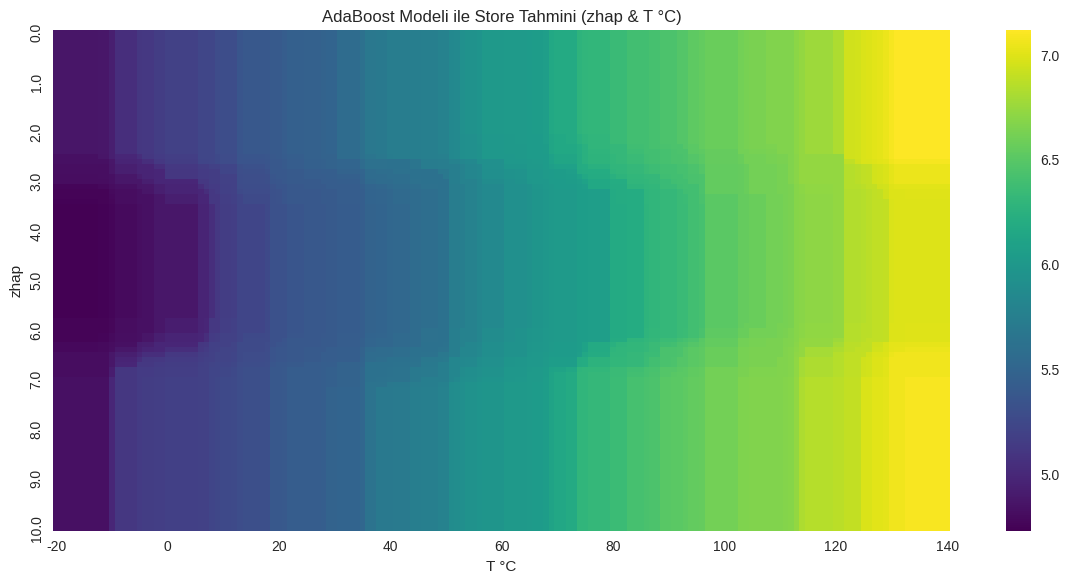

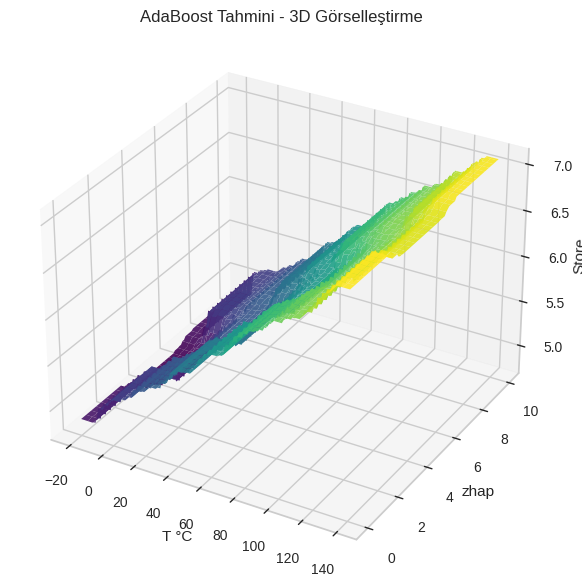

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.regression import *
from mpl_toolkits.mplot3d import Axes3D

# 1. Eğitim verisini üret (zhap & T °C etkisi olan)
np.random.seed(42)
n_samples = 2000

df_train = pd.DataFrame({
    'T °C': np.random.uniform(-20, 140, n_samples),
    'zhap': np.random.uniform(0, 10, n_samples)
})
df_train['ZnO(wt%)'] = 0.0
df_train['Name'] = 'Sample'
df_train['Loss'] = 0.01
df_train['Tan Delta'] = 0.05

# Store = T + sin(zhap) + küçük gürültü → Model öğrenecek
df_train['Store'] = (
    0.015 * df_train['T °C'] +
    0.4 * np.sin(df_train['zhap']) +
    5 + np.random.normal(0, 0.05, n_samples)
)

# 2. PyCaret ile AdaBoost modeli eğit
setup(df_train, target='Store', session_id=123)
ada_model = create_model('ada')

# 3. Tahmin için test verisi üret (grid)
t_values = np.arange(-20, 141, 1)
zhap_values = np.arange(0.0, 10.1, 0.1)
T_grid, ZHAP_grid = np.meshgrid(t_values, zhap_values)

df_test = pd.DataFrame({
    'T °C': T_grid.ravel(),
    'zhap': ZHAP_grid.ravel(),
    'ZnO(wt%)': 0.0,
    'Name': 'Sample',
    'Loss': 0.01,
    'Tan Delta': 0.05
})

# 4. Tahmin yap
df_pred = predict_model(ada_model, data=df_test)
df_pred = df_pred.rename(columns={'prediction_label': 'Tahmin Store'})

# 5. Görselleştir: 2D Isı Haritası
pivot = df_pred.pivot(index='zhap', columns='T °C', values='Tahmin Store')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='viridis', xticklabels=20, yticklabels=10)
plt.title("AdaBoost Modeli ile Store Tahmini (zhap & T °C)")
plt.xlabel("T °C")
plt.ylabel("zhap")
plt.tight_layout()
plt.show()

# 6. (Opsiyonel) 3D yüzey grafiği
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T_grid, ZHAP_grid, df_pred['Tahmin Store'].values.reshape(ZHAP_grid.shape),
                cmap='viridis', edgecolor='none', alpha=0.9)
ax.set_xlabel("T °C")
ax.set_ylabel("zhap")
ax.set_zlabel("Store")
ax.set_title("AdaBoost Tahmini - 3D Görselleştirme")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from pycaret.regression import *

# 1. Eğitim verisi üret (simülasyon)
import numpy as np
np.random.seed(42)
n = 1000
df_train = pd.DataFrame({
    'T °C': np.random.uniform(-20, 140, n),
    'zhap': np.random.uniform(0, 10, n),
    'Loss': np.random.uniform(0.005, 0.02, n),
    'Tan Delta': np.random.uniform(0.04, 0.07, n),
    'ZnO(wt%)': 0.0,
    'Name': ['Sample'] * n
})
df_train['Store'] = (
    0.015 * df_train['T °C'] +
    0.4 * np.sin(df_train['zhap']) +
    0.3 * df_train['Loss'] +
    0.2 * df_train['Tan Delta'] +
    5 + np.random.normal(0, 0.05, n)
)

# 2. PyCaret modeli kur ve ada modelini eğit
setup(df_train, target='Store', session_id=123)
ada_model = create_model('ada')

# 3. Elle giriş al
print("\n📝 Lütfen aşağıdaki değerleri girin:")

t = float(input("T °C: "))
zhap = float(input("zhap: "))
loss = float(input("Loss: "))
tan_delta = float(input("Tan Delta: "))
zno = float(input("ZnO(wt%): "))
name = input("Name (örnek: Sample): ")

# 4. Tahmin için DataFrame oluştur
input_data = pd.DataFrame({
    'T °C': [t],
    'zhap': [zhap],
    'Loss': [loss],
    'Tan Delta': [tan_delta],
    'ZnO(wt%)': [zno],
    'Name': [name]
})

# 5. Tahmini hesapla
prediction = predict_model(ada_model, data=input_data)
predicted_value = prediction['prediction_label'].values[0]

print(f"\n🔮 Tahmin Edilen Store Değeri: {predicted_value:.4f}")


ModuleNotFoundError: No module named 'pycaret'

In [ ]:



model_tan = create_model('rf')

# LOSS MODELİ

model_loss = create_model('et')

# Tan Delta ve Loss tahminlerini ekle (sütun adlarını koruyoruz!)
df['Pred_Tan Delta'] = predict_model(model_tan, data=df)['prediction_label']
df['Pred_Loss'] = predict_model(model_loss, data=df)['prediction_label']

# STORE MODELİ için uygun formatta veri hazırla
df_store = df[['T °C', 'zhap', 'ZnO(wt%)', 'Pred_Loss', 'Pred_Tan Delta', 'Store']].dropna()

model_store = create_model('ada')

# TAHMİN YAPILACAK GİRİŞLERİ HAZIRLA
temps = np.arange(-20, 141, 1)
zhap_range = np.arange(0.5, 5.1, 0.5)
znO = 0.0
results = []

for zhap in zhap_range:
    df_input = pd.DataFrame({
        'T °C': temps,
        'zhap': zhap,
        'ZnO(wt%)': znO,
        'Name': ['Simulated'] * len(temps)
    })

    # Tan Delta ve Loss tahmini
    df_input['Pred_Tan Delta'] = predict_model(model_tan, data=df_input)['prediction_label']
    df_input['Pred_Loss'] = predict_model(model_loss, data=df_input)['prediction_label']

    # Store tahmini (dikkat: sütun adları değişmedi!)
    df_input['Store'] = predict_model(model_store, data=df_input)['prediction_label']

    # Diğer verilerle birlikte kaydet
    df_input['zhap'] = zhap
    results.append(df_input)

# TÜM SONUÇLARI BİRLEŞTİR
df_result = pd.concat(results, ignore_index=True)

# GÖRSELLEŞTİRME
plt.figure(figsize=(16, 12))

plt.subplot(3, 1, 1)
sns.lineplot(data=df_result, x='T °C', y='Store', hue='zhap', palette='viridis')
plt.title('Store vs. Sıcaklık')
plt.ylabel('Store')

plt.subplot(3, 1, 2)
sns.lineplot(data=df_result, x='T °C', y='Pred_Loss', hue='zhap', palette='magma')
plt.title('Loss vs. Sıcaklık')
plt.ylabel('Loss')

plt.subplot(3, 1, 3)
sns.lineplot(data=df_result, x='T °C', y='Pred_Tan Delta', hue='zhap', palette='plasma')
plt.title('Tan Delta vs. Sıcaklık')
plt.ylabel('Tan Delta')
plt.xlabel('T °C')

plt.tight_layout()
plt.show()

# TABLO GÖSTER
df_final = df_result[['T °C', 'zhap', 'Pred_Tan Delta', 'Pred_Loss', 'Store']].round(4)
df_final.head(20)


NameError: name 'create_model' is not defined